# Preprocessing Data NO<sub>2</sub> Kabupaten Bangkalan

## **Penanganan Missing Values**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

**Penjelasan:**
- pandas: Library untuk manipulasi dan analisis data
- matplotlib.pyplot: Library untuk visualisasi data dan grafik

In [2]:
NO2 = pd.read_csv('no2_results/no2_bangkalan_data.csv')
NO2 = NO2.sort_values(by='date')
NO2

,date,feature_index,NO2
262,2024-12-31T00:00:00.000Z,0,NaN
259,2025-01-01T00:00:00.000Z,0,NaN
257,2025-01-02T00:00:00.000Z,0,NaN
260,2025-01-03T00:00:00.000Z,0,0.000040
256,2025-01-04T00:00:00.000Z,0,NaN
...,...,...,...
255,2025-09-26T00:00:00.000Z,0,0.000019
249,2025-09-27T00:00:00.000Z,0,0.000017
254,2025-09-28T00:00:00.000Z,0,0.000017
273,2025-09-29T00:00:00.000Z,0,0.000028


**Penjelasan:**
- Memuat dataset NO₂ dari file CSV hasil pengambilan data satelit
- Mengurutkan data berdasarkan tanggal untuk memastikan urutan temporal yang benar
- Menampilkan dataset untuk inspeksi awal

In [3]:
NO2.isnull().sum()

date               0
feature_index      0
NO2              102
dtype: int64

**Penjelasan:** Menghitung jumlah missing values pada setiap kolom untuk mengidentifikasi tingkat kelengkapan data.

C:\Users\Harits Putra Junaidi\AppData\Local\Temp\ipykernel_3896\800750193.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(i, v + 0.5, f"{v} ({missing_percent[i]:.1f}%)",


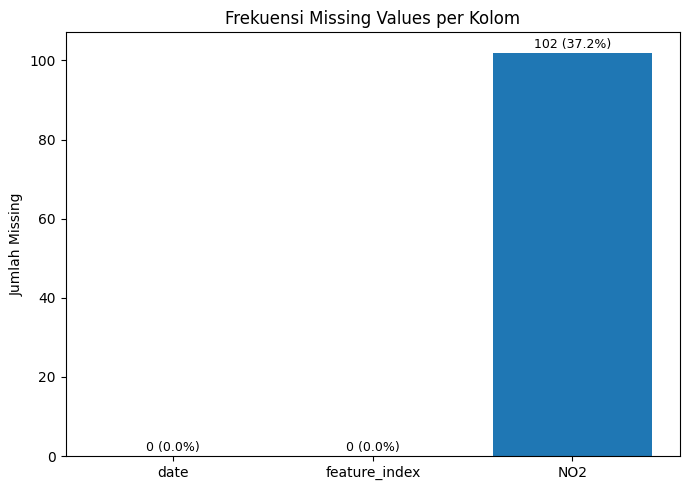

,Missing Count,Missing Percent (%)
date,0,0.00
feature_index,0,0.00
NO2,102,37.23


In [4]:
missing_count = NO2.isnull().sum()
missing_percent = (missing_count / len(NO2)) * 100

fig, ax = plt.subplots(figsize=(7,5))

bars = ax.bar(missing_count.index, missing_count)

ax.set_title("Frekuensi Missing Values per Kolom")
ax.set_ylabel("Jumlah Missing")

for i, v in enumerate(missing_count):
    ax.text(i, v + 0.5, f"{v} ({missing_percent[i]:.1f}%)",
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

missing_table = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percent (%)': missing_percent.round(2)
})

missing_table

**Penjelasan:**
- Membuat visualisasi bar chart untuk missing values
- Menampilkan jumlah dan persentase missing values di atas setiap bar
- Membuat tabel summary missing values untuk dokumentasi

In [5]:
NO2 = pd.Series(NO2['NO2'].values, index=NO2['date'], name='NO2')
NO2 = NO2.interpolate(method='linear').bfill()
NO2 = pd.DataFrame(NO2).reset_index()
NO2

,date,NO2
0,2024-12-31T00:00:00.000Z,0.000040
1,2025-01-01T00:00:00.000Z,0.000040
2,2025-01-02T00:00:00.000Z,0.000040
3,2025-01-03T00:00:00.000Z,0.000040
4,2025-01-04T00:00:00.000Z,0.000038
...,...,...
269,2025-09-26T00:00:00.000Z,0.000019
270,2025-09-27T00:00:00.000Z,0.000017
271,2025-09-28T00:00:00.000Z,0.000017
272,2025-09-29T00:00:00.000Z,0.000028


**Penjelasan:**
- Konversi ke Series: Mengubah data menjadi pandas Series dengan index tanggal
- Linear Interpolation: Mengisi missing values dengan interpolasi linear berdasarkan nilai sebelum dan sesudahnya
- Backward Fill: Mengisi missing values yang tersisa dengan nilai valid berikutnya
- Konversi kembali: Mengubah kembali ke DataFrame dan reset index
- Metode ini mempertahankan pola temporal data

In [6]:
NO2.isnull().sum()

date    0
NO2     0
dtype: int64

**Penjelasan:** Memverifikasi bahwa semua missing values telah berhasil ditangani setelah proses interpolasi dan backward fill.

In [7]:
missing_count = NO2.isnull().sum()
missing_percent = (missing_count / len(NO2)) * 100

missing_table = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percent (%)': missing_percent.round(2)
})

missing_table

,Missing Count,Missing Percent (%)
date,0,0.0
NO2,0,0.0


**Penjelasan:** Membuat tabel summary untuk mendokumentasikan bahwa tidak ada lagi missing values setelah proses imputasi.

In [8]:
NO2 = NO2.drop(columns='date')
NO2 = pd.DataFrame(NO2)
NO2

,NO2
0,0.000040
1,0.000040
2,0.000040
3,0.000040
4,0.000038
...,...
269,0.000019
270,0.000017
271,0.000017
272,0.000028


**Penjelasan:**
- Menghapus kolom 'date' karena tidak diperlukan untuk modeling time series
- Memastikan data dalam format DataFrame yang bersih
- Memfokuskan data hanya pada nilai NO₂ untuk proses supervised learning

## **Deteksi Dan Penanganan Outlier Menggunakan LOF**

Outlier terdeteksi: 28 dari 274 data (10.22%)
NO2: 0 nilai < -0.000006 dan 4 nilai > 0.000060


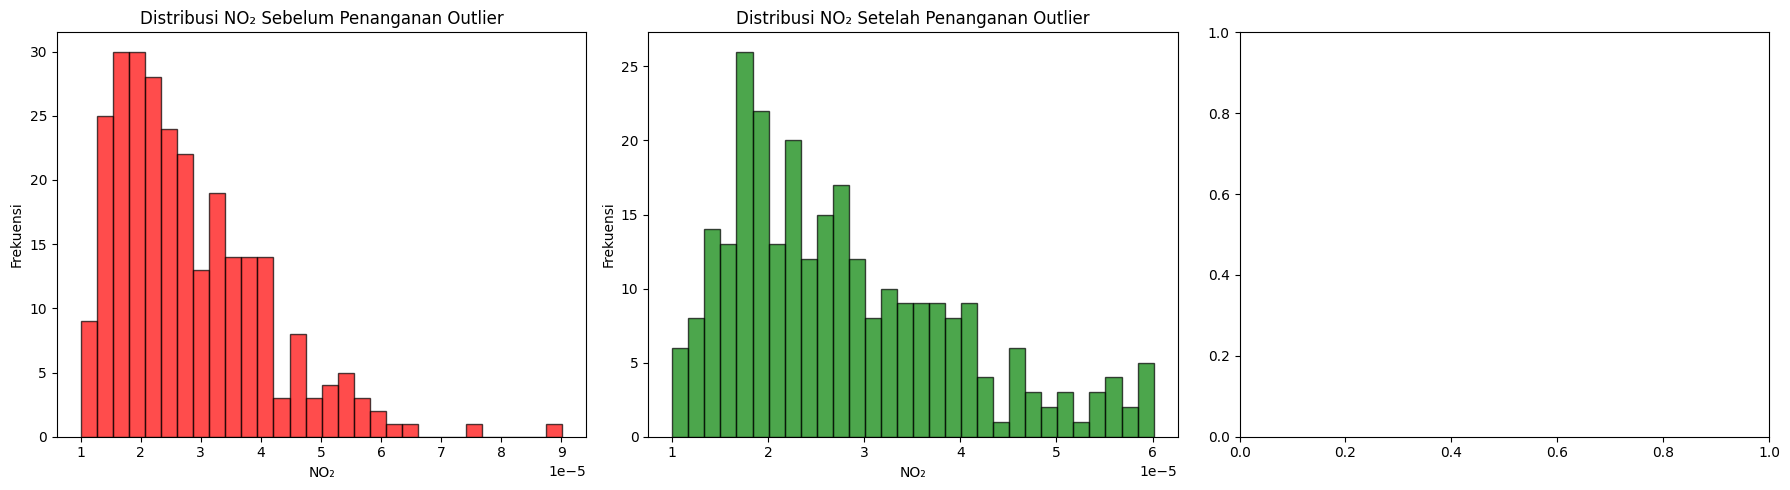

In [9]:
from sklearn.neighbors import LocalOutlierFactor
import numpy as np

# Deteksi outlier menggunakan LOF pada kolom NO2
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
outlier_labels = lof.fit_predict(NO2[['NO2']])

# Identifikasi outlier
outlier_mask = outlier_labels == -1
n_outliers_before = sum(outlier_mask)

print(f"Outlier terdeteksi: {n_outliers_before} dari {len(NO2)} data ({(n_outliers_before/len(NO2)*100):.2f}%)")

# Visualisasi outlier
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


# Distribusi sebelum penanganan
axes[0].hist(NO2['NO2'], bins=30, alpha=0.7, color='red', edgecolor='black')
axes[0].set_title('Distribusi NO₂ Sebelum Penanganan Outlier')
axes[0].set_xlabel('NO₂')
axes[0].set_ylabel('Frekuensi')


# Penanganan outlier menggunakan IQR capping
Q1 = NO2['NO2'].quantile(0.25)
Q3 = NO2['NO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Hitung outlier sebelum capping
outlier_count_lower = sum(NO2['NO2'] < lower_bound)
outlier_count_upper = sum(NO2['NO2'] > upper_bound)

print(f"NO2: {outlier_count_lower} nilai < {lower_bound:.6f} dan {outlier_count_upper} nilai > {upper_bound:.6f}")

# Capping outlier
NO2['NO2'] = np.clip(NO2['NO2'], lower_bound, upper_bound)


# Distribusi setelah penanganan
axes[1].hist(NO2['NO2'], bins=30, alpha=0.7, color='green', edgecolor='black')
axes[1].set_title('Distribusi NO₂ Setelah Penanganan Outlier')
axes[1].set_xlabel('NO₂')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

# Verifikasi hasil
lof_verify = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
outlier_labels_after = lof_verify.fit_predict(NO2[['NO2']])
n_outliers_after = sum(outlier_labels_after == -1)

# print(f"\nHasil setelah penanganan outlier:")
# print(f"Outlier tersisa: {n_outliers_after} dari {len(NO2)} data ({(n_outliers_after/len(NO2)*100):.2f}%)")
# print(f"Pengurangan outlier: {n_outliers_before - n_outliers_after} data")
# print("✓ Outlier telah ditangani, data siap untuk supervised learning\n")

## **Membentuk data supervised**

In [10]:
day1 = NO2
day2 = NO2
day3 = NO2
day4 = NO2
day5 = NO2

**Penjelasan:** Membuat 5 copy dari dataset untuk membuat variasi lag features (1-5 hari). Setiap dataset akan digunakan untuk eksperimen dengan jumlah lag yang berbeda.

### - Membuat data supervised menggunakan t1

In [11]:
n_lags = 1
for i in range(1, n_lags + 1):
    day1[f't-{i}'] = day1['NO2'].shift(i)

day1 = day1.dropna().reset_index(drop=True)
day1.to_csv('no2_results/day1_supervised.csv', index=False)
day1


,NO2,t-1
0,0.000040,0.000040
1,0.000040,0.000040
2,0.000040,0.000040
3,0.000038,0.000040
4,0.000036,0.000038
...,...,...
268,0.000019,0.000018
269,0.000017,0.000019
270,0.000017,0.000017
271,0.000028,0.000017


### - Membuat data supervised menggunakan t1, t2

In [12]:
n_lags = 2
for i in range(1, n_lags + 1):
    day2[f't-{i}'] = day2['NO2'].shift(i)

day2 = day2.dropna().reset_index(drop=True)
day2.to_csv('no2_results/day2_supervised.csv', index=False)
day2


,NO2,t-1,t-2
0,0.000040,0.000040,0.000040
1,0.000040,0.000040,0.000040
2,0.000038,0.000040,0.000040
3,0.000036,0.000038,0.000040
4,0.000034,0.000036,0.000038
...,...,...,...
267,0.000019,0.000018,0.000051
268,0.000017,0.000019,0.000018
269,0.000017,0.000017,0.000019
270,0.000028,0.000017,0.000017


### - Membuat data supervised menggunakan t1, t2, t3

In [13]:
n_lags = 3
for i in range(1, n_lags + 1):
    day3[f't-{i}'] = day3['NO2'].shift(i)

day3 = day3.dropna().reset_index(drop=True)
day3.to_csv('no2_results/day3_supervised.csv', index=False)
day3


,NO2,t-1,t-2,t-3
0,0.000040,0.000040,0.000040,0.000040
1,0.000038,0.000040,0.000040,0.000040
2,0.000036,0.000038,0.000040,0.000040
3,0.000034,0.000036,0.000038,0.000040
4,0.000039,0.000034,0.000036,0.000038
...,...,...,...,...
266,0.000019,0.000018,0.000051,0.000047
267,0.000017,0.000019,0.000018,0.000051
268,0.000017,0.000017,0.000019,0.000018
269,0.000028,0.000017,0.000017,0.000019


### - Membuat data supervised menggunakan t1, t2, t3, t4

In [14]:
n_lags = 4
for i in range(1, n_lags + 1):
    day4[f't-{i}'] = day4['NO2'].shift(i)

day4 = day4.dropna().reset_index(drop=True)
day4.to_csv('no2_results/day4_supervised.csv', index=False)
day4


,NO2,t-1,t-2,t-3,t-4
0,0.000038,0.000040,0.000040,0.000040,0.000040
1,0.000036,0.000038,0.000040,0.000040,0.000040
2,0.000034,0.000036,0.000038,0.000040,0.000040
3,0.000039,0.000034,0.000036,0.000038,0.000040
4,0.000022,0.000039,0.000034,0.000036,0.000038
...,...,...,...,...,...
265,0.000019,0.000018,0.000051,0.000047,0.000022
266,0.000017,0.000019,0.000018,0.000051,0.000047
267,0.000017,0.000017,0.000019,0.000018,0.000051
268,0.000028,0.000017,0.000017,0.000019,0.000018


### - Membuat data supervised menggunakan t1, t2, t3, t4, t5

In [15]:
n_lags = 5
for i in range(1, n_lags + 1):
    day5[f't-{i}'] = day5['NO2'].shift(i)

day5 = day5.dropna().reset_index(drop=True)
day5.to_csv('no2_results/day5_supervised.csv', index=False)
day5


,NO2,t-1,t-2,t-3,t-4,t-5
0,0.000036,0.000038,0.000040,0.000040,0.000040,0.000040
1,0.000034,0.000036,0.000038,0.000040,0.000040,0.000040
2,0.000039,0.000034,0.000036,0.000038,0.000040,0.000040
3,0.000022,0.000039,0.000034,0.000036,0.000038,0.000040
4,0.000034,0.000022,0.000039,0.000034,0.000036,0.000038
...,...,...,...,...,...,...
264,0.000019,0.000018,0.000051,0.000047,0.000022,0.000010
265,0.000017,0.000019,0.000018,0.000051,0.000047,0.000022
266,0.000017,0.000017,0.000019,0.000018,0.000051,0.000047
267,0.000028,0.000017,0.000017,0.000019,0.000018,0.000051


## **Korelasi lag features dengan NO2**

In [16]:
def analyze_lag_correlation_with_threshold(datasets_dict, correlation_threshold=0.5):

    results = {}
    
    for dataset_name, df in datasets_dict.items():
        print(f"\n--- Analisis Dataset {dataset_name.upper()} ---")
        
        # Identifikasi kolom lag
        lag_columns = [col for col in df.columns if col.startswith('t-')]
        target_column = 'NO2'
        
        if not lag_columns:
            print(f"Tidak ada lag features dalam {dataset_name}")
            continue
            
        correlations = {}
        selected_features = [target_column]  # Selalu include target
        
        for col in sorted(lag_columns, key=lambda x: int(x.split('-')[1])):
            # Hitung korelasi
            correlation = df[target_column].corr(df[col])
            abs_correlation = abs(correlation)
            
            correlations[col] = {
                'correlation': correlation,
                'abs_correlation': abs_correlation
            }
            
            # Tentukan apakah feature dipilih berdasarkan threshold
            if abs_correlation >= correlation_threshold:
                selected_features.append(col)
                status = "DIPILIH"
                color_symbol = "🟢"
            else:
                status = "TIDAK DIPILIH"  
                color_symbol = "🔴"
            
            lag_num = col.split('-')[1]
            print(f"{color_symbol} Lag {lag_num}: {correlation:+.4f} ({abs_correlation:.1%}) - {status}")
        
        # Filter dataset berdasarkan selected features
        df_filtered = df[selected_features].copy()
        
        # Simpan dataset yang sudah difilter
        filtered_filename = f'no2_results/{dataset_name}_supervised_filtered.csv'
        df_filtered.to_csv(filtered_filename, index=False)
        
        results[dataset_name] = {
            'original_df': df,
            'filtered_df': df_filtered,
            'selected_features': selected_features,
            'correlations': correlations,
            'n_lags_total': len(lag_columns),
            'n_lags_selected': len([f for f in selected_features if f.startswith('t-')]),
            'filtered_filename': filtered_filename
        }
        
        print(f"Features terpilih: {len(selected_features)}/{len(df.columns)} "
              f"(Lags: {len([f for f in selected_features if f.startswith('t-')])}/{len(lag_columns)})")
        print(f"Dataset filtered disimpan: {filtered_filename}")
    
    return results


--- Analisis Dataset DAY1 ---
🟢 Lag 1: +0.6125 (61.2%) - DIPILIH
Features terpilih: 2/2 (Lags: 1/1)
Dataset filtered disimpan: no2_results/day1_supervised_filtered.csv

--- Analisis Dataset DAY2 ---
🟢 Lag 1: +0.6109 (61.1%) - DIPILIH
🔴 Lag 2: +0.3559 (35.6%) - TIDAK DIPILIH
Features terpilih: 2/3 (Lags: 1/2)
Dataset filtered disimpan: no2_results/day2_supervised_filtered.csv

--- Analisis Dataset DAY3 ---
🟢 Lag 1: +0.6092 (60.9%) - DIPILIH
🔴 Lag 2: +0.3532 (35.3%) - TIDAK DIPILIH
🔴 Lag 3: +0.2580 (25.8%) - TIDAK DIPILIH
Features terpilih: 2/4 (Lags: 1/3)
Dataset filtered disimpan: no2_results/day3_supervised_filtered.csv

--- Analisis Dataset DAY4 ---
🟢 Lag 1: +0.6076 (60.8%) - DIPILIH
🔴 Lag 2: +0.3504 (35.0%) - TIDAK DIPILIH
🔴 Lag 3: +0.2548 (25.5%) - TIDAK DIPILIH
🔴 Lag 4: +0.2490 (24.9%) - TIDAK DIPILIH
Features terpilih: 2/5 (Lags: 1/4)
Dataset filtered disimpan: no2_results/day4_supervised_filtered.csv

--- Analisis Dataset DAY5 ---
🟢 Lag 1: +0.6062 (60.6%) - DIPILIH
🔴 Lag 2: +0.

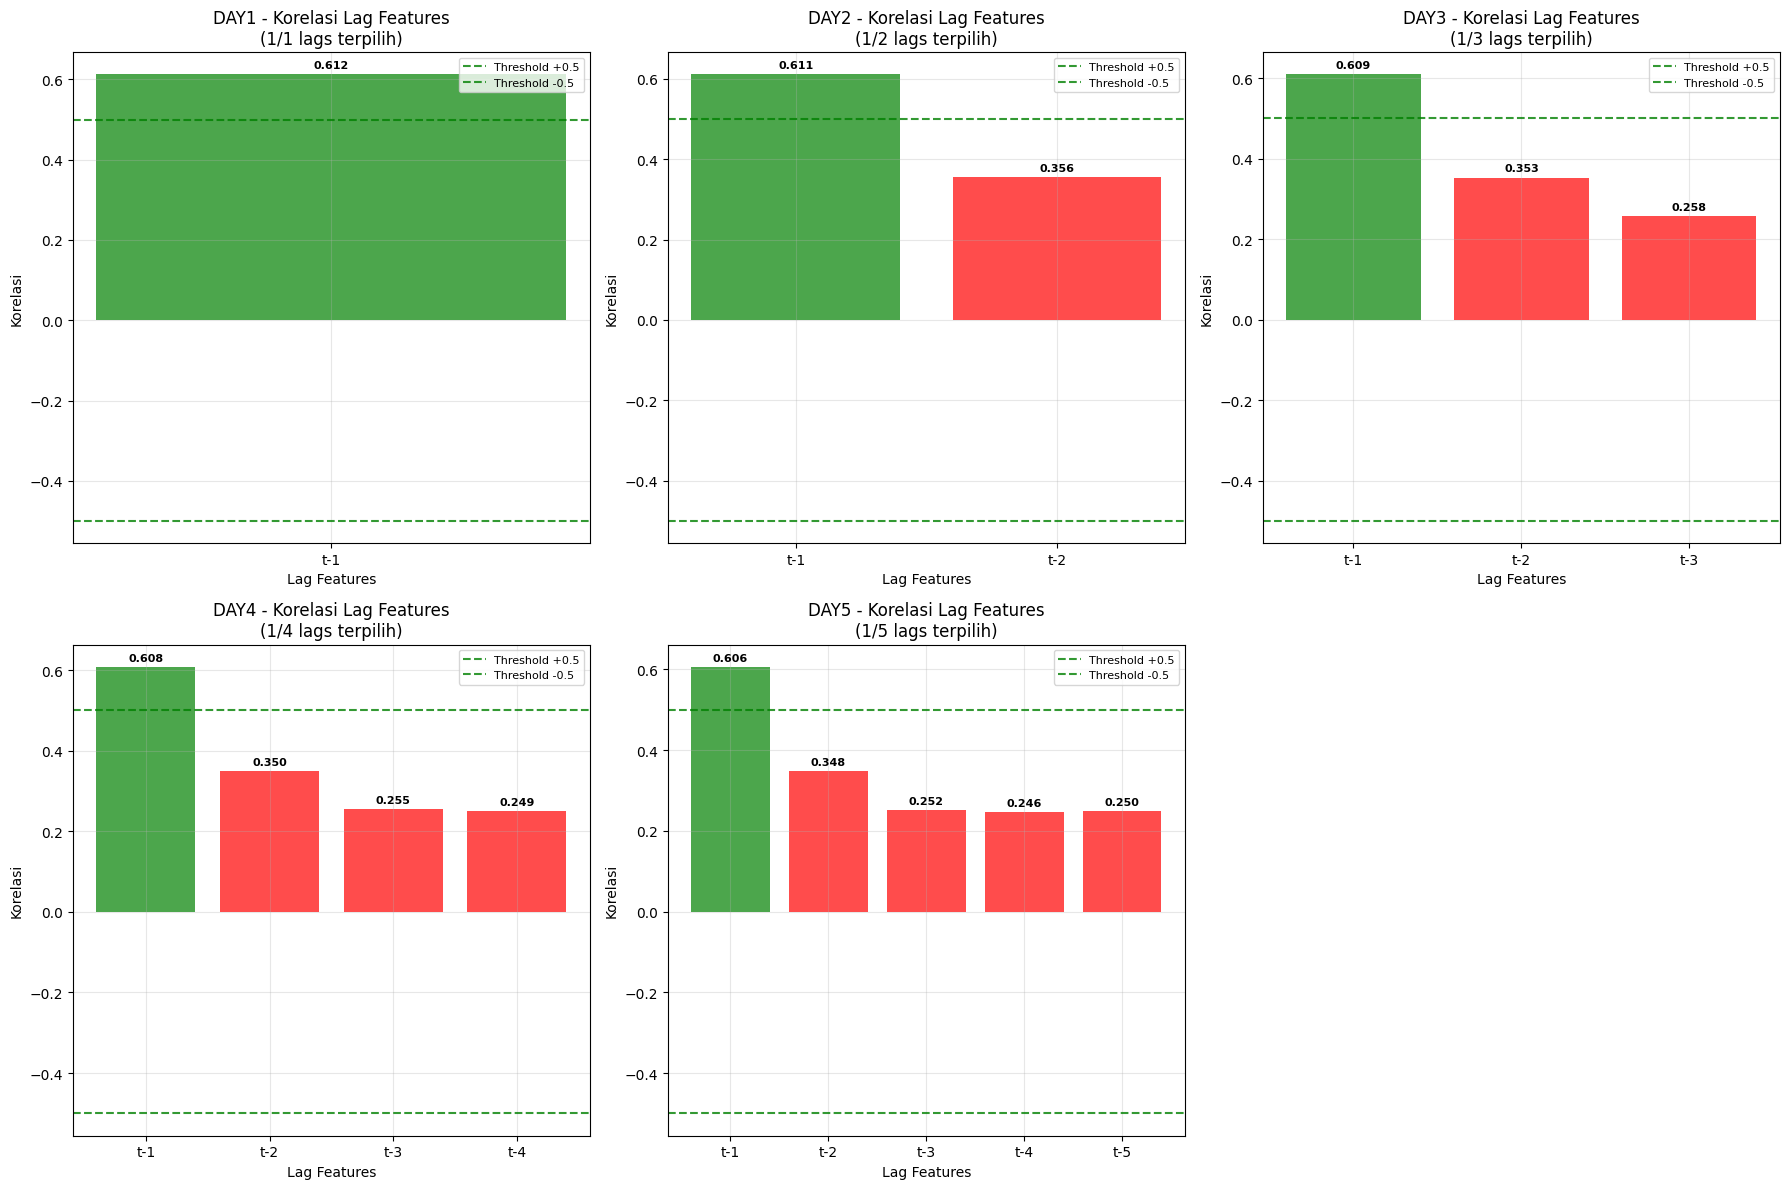

In [17]:
# Kumpulkan semua dataset supervised
supervised_datasets = {
    'day1': day1,
    'day2': day2, 
    'day3': day3,
    'day4': day4,
    'day5': day5
}

# analisis korelasi dengan threshold 0.5
correlation_threshold = 0.5 
correlation_results = analyze_lag_correlation_with_threshold(supervised_datasets, correlation_threshold)

# Visualisasi korelasi untuk semua datasets
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (dataset_name, result) in enumerate(correlation_results.items()):
    if idx >= len(axes):
        break
        
    correlations = result['correlations']
    
    if correlations:
        lag_numbers = [int(col.split('-')[1]) for col in correlations.keys()]
        correlation_values = [correlations[f't-{lag}']['correlation'] for lag in sorted(lag_numbers)]
        
        colors = ['green' if abs(corr) >= correlation_threshold else 'red' for corr in correlation_values]
        
        bars = axes[idx].bar([f't-{lag}' for lag in sorted(lag_numbers)], 
                           correlation_values, color=colors, alpha=0.7)
        
        # Garis threshold
        axes[idx].axhline(y=correlation_threshold, color='green', linestyle='--', alpha=0.8, label=f'Threshold +{correlation_threshold}')
        axes[idx].axhline(y=-correlation_threshold, color='green', linestyle='--', alpha=0.8, label=f'Threshold -{correlation_threshold}')
        
        axes[idx].set_title(f'{dataset_name.upper()} - Korelasi Lag Features\n({result["n_lags_selected"]}/{result["n_lags_total"]} lags terpilih)')
        axes[idx].set_ylabel('Korelasi')
        axes[idx].set_xlabel('Lag Features')
        axes[idx].grid(True, alpha=0.3)
        axes[idx].legend(fontsize=8)
        
        # nilai korelasi di atas bar
        for bar, corr in zip(bars, correlation_values):
            height = bar.get_height()
            axes[idx].text(bar.get_x() + bar.get_width()/2., 
                          height + (0.01 if height >= 0 else -0.03),
                          f'{corr:.3f}', ha='center', 
                          va='bottom' if height >= 0 else 'top', fontsize=8, fontweight='bold')

for idx in range(len(correlation_results), len(axes)):
    axes[idx].remove()

plt.tight_layout()
plt.show()